In [1]:
# ch04_LANGGRAPH_ARCHITECTURE.ipynb

In [2]:
# 출력 구조화 

from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model

# 1) 스키마 정의
class SearchQuery(BaseModel):
    search_query: str = Field(..., description="웹 검색에 최적화된 질의문")
    justification: str = Field(..., description="해당 질의가 왜 적절한지의 근거")

# 2) 구조화된 출력으로 LLM 래핑
from llm import get_llm
llm = get_llm()
structured_llm = llm.with_structured_output(SearchQuery)

# 3) 프롬프트 실행
prompt = "랭그래프가 왜 필요한가?"
result = structured_llm.invoke(prompt)
print("result :", result)

# 4) 사용
print("검색어:", result.search_query)
print("근거:", result.justification)

result : search_query='LangGraph 필요성 이유 장점 용도' justification='사용자가 LangGraph가 왜 필요한지에 대해 질문했으므로, LangGraph의 필요성, 이유, 장점, 용도 등에 대한 최신 정보를 검색해야 합니다.'
검색어: LangGraph 필요성 이유 장점 용도
근거: 사용자가 LangGraph가 왜 필요한지에 대해 질문했으므로, LangGraph의 필요성, 이유, 장점, 용도 등에 대한 최신 정보를 검색해야 합니다.


In [3]:
# 도구 호출

# 1) 도구 정의
def multiply(a: int, b: int) -> int:
    """두 수의 곱을 반환"""
    return a * b

# 2) LLM에 도구 바인딩
agent = llm.bind_tools([multiply])

# 3) 사용자 질문
user_msg = "2 곱하기 3은?"

# 4) 1차 LLM 호출 -> 도구 호출 의도 파악
msg = agent.invoke(user_msg)

# 5) tool_calls 확인 및 실행
results = {}
print(msg.tool_calls)

for call in getattr(msg, "tool_calls", []):
    name = call["name"]
    args = call["args"]
    if name == "multiply":
        results[name] = multiply(**args)
print(results)

[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'toolu_bdrk_01PoR4sqdFxHNewLW7Cfw9rd', 'type': 'tool_call'}]
{'multiply': 6}


In [4]:
# 프롬프트 체이닝 

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


In [5]:
# 1) 농담 생성
def generate_joke(state: State):
    msg = llm.invoke(f"{state['topic']}에 대한 짧은 농담을 작성해 주세요.")
    return {"joke": msg.content}

# 2) 품질 검사(펀치라인 확인)
def check_punchline(state: State):
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"

# 3) 농담 개선
def improve_joke(state: State):
    msg = llm.invoke(f"다음 농담에 말장난을 넣어 더 재미있게 만들어 주세요: {state['joke']}")
    return {"improved_joke": msg.content}

# 4) 농담 다듬기
def polish_joke(state: State):
    msg = llm.invoke(f"다음 농담에 예상치 못한 반전을 추가해 주세요: {state['improved_joke']}")
    return {"final_joke": msg.content}


In [6]:
workflow = StateGraph(State)

# 노드 등록
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# 순서 연결
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# 워크플로 컴파일
chain = workflow.compile()


In [7]:
state = chain.invoke({"topic": "한국"})

print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")

if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("농담이 품질 검사를 통과하여 개선이 필요하지 않습니다!")


Initial joke:
여기 한국에 대한 가벼운 농담 하나 있어요:

"한국인이 해외여행을 가면 왜 항상 라면을 챙겨갈까요?
현지 음식이 입에 안 맞을 때를 대비해서가 아니라... 
현지 음식이 너무 맛있어서 한국 라면이 그리워질까봐서요!"

한국인의 라면 사랑을 소재로 한 따뜻한 농담이었습니다. 😊

--- --- ---

농담이 품질 검사를 통과하여 개선이 필요하지 않습니다!


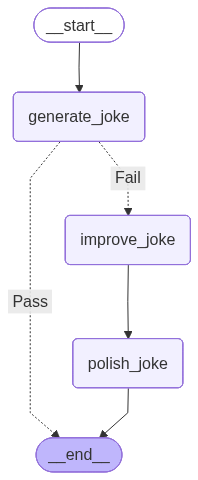

In [13]:
from IPython.display import Image, display

# 다이어그램 출력
display(Image(chain.get_graph().draw_mermaid_png()))


In [8]:
# 병렬 처리

# 상태 정의
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# 1) 농담 생성
def call_llm_1(state: State):
    msg = llm.invoke(f"{state['topic']}에 대한 농담을 작성해 주세요.")
    return {"joke": msg.content}

# 2) 이야기 생성
def call_llm_2(state: State):
    msg = llm.invoke(f"{state['topic']}에 대한 이야기를 짧게 작성해 주세요.")
    return {"story": msg.content}

# 3) 시 생성
def call_llm_3(state: State):
    msg = llm.invoke(f"{state['topic']}에 대한 시를 작성해 주세요.")
    return {"poem": msg.content}

# 4) 결과 합치기
def aggregator(state: State):
    combined = f"{state['topic']}에 관한 이야기, 농담, 시입니다!\n\n"
    combined += f"이야기:\n{state['story']}\n\n"
    combined += f"농담:\n{state['joke']}\n\n"
    combined += f"시:\n{state['poem']}"
    return {"combined_output": combined}


In [10]:
parallel_builder = StateGraph(State)

# 노드 등록
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# 병렬 연결
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")

# 결과 합치기
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)

# 컴파일
parallel_workflow = parallel_builder.compile()


In [11]:
state = parallel_workflow.invoke({"topic": "한국"})
print(state["combined_output"])

한국에 관한 이야기, 농담, 시입니다!

이야기:
**한반도의 작은 기적**

세계 지도에서 작은 반도 하나가 있습니다. 70년 전까지만 해도 전쟁의 상처로 폐허가 된 이 땅에서, 사람들은 맨손으로 다시 일어섰습니다.

아침이면 김치찌개 냄새가 골목을 가득 채우고, 할머니들은 여전히 "밥 먹었니?"라고 안부를 묻습니다. 사계절이 뚜렷한 이 땅에서 벚꽃이 피면 온 나라가 설레고, 단풍이 지면 모두가 추억에 잠깁니다.

한강에서 시작된 작은 변화는 이제 전 세계로 퍼져나갑니다. K-pop 멜로디가 지구 반대편에서 울려 퍼지고, 한국 드라마를 보며 함께 울고 웃는 사람들이 늘어갑니다.

빨리빠리 문화와 정(情)이 공존하는 이곳, 첨단 기술과 전통이 어우러진 이곳이 바로 한국입니다. 여전히 완벽하지 않지만, 오늘도 더 나은 내일을 꿈꾸며 앞으로 나아가고 있습니다.

농담:
다음은 한국에 대한 친근한 농담들입니다:

**1. 한국의 빠른 인터넷**
외국인: "한국 인터넷이 얼마나 빨라요?"
한국인: "영화 다운로드가 끝나기 전에 영화관에서 영화가 끝나요."

**2. 한국의 치킨집**
"한국에는 치킨집이 몇 개나 있나요?"
"집 개수보다 많아요."

**3. 한국의 교육열**
한국 엄마: "우리 아이가 의대 못 가면 어떡하지?"
아이: "엄마, 저 아직 5살이에요..."

**4. 한국의 커피 사랑**
"한국인은 언제 커피를 마시나요?"
"숨 쉴 때요."

**5. 한국의 사계절**
"한국의 사계절은 뭔가요?"
"봄: 짧음, 여름: 더움, 가을: 짧음, 겨울: 추움"

이런 농담들은 한국의 특징들을 재미있게 표현한 것으로, 애정 어린 시선에서 만들어진 것들입니다! 😊

시:
**한국**

산들이 품은 아침 안개 속에
오천년 역사가 숨쉬고 있네
한강이 흘러 바다로 향하듯
우리의 꿈도 끝없이 흘러가네

봄이면 벚꽃이 거리를 수놓고
여름엔 매미 소리 가득하며
가을엔 단풍이 산을 물들이고
겨울엔 하얀 눈이 세상을 덮네

할머니의 손맛 담긴 김치와
어머니가 끓여준 따뜻한 국물


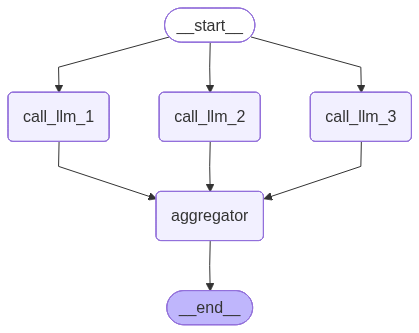

In [12]:
from IPython.display import Image, display

# 다이어그램 출력
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))


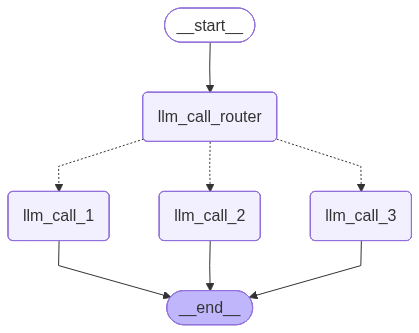

여기 한국에 대한 가벼운 농담 몇 개를 준비했어요:

**농담 1:**
외국인: "한국 사람들은 정말 빨라요!"
한국인: "뭐가요?"
외국인: "배달음식이요. 주문하기도 전에 벌써 문 앞에 와있더라고요!"

**농담 2:**
한국의 4계절:
- 봄: 미세먼지
- 여름: 장마+폭염
- 가을: 태풍
- 겨울: 한파
그래도 사계절이 뚜렷하다고 자랑하는 한국인들 😄

**농담 3:**
외국인이 한국어를 배우다가 포기한 이유:
"안녕하세요"를 배웠는데, 
아침엔 "안녕하세요", 점심엔 "안녕하세요", 저녁에도 "안녕하세요"...
"이 나라 사람들은 하루 종일 안녕한지만 확인하는군!"

가벼운 마음으로 즐겨주세요! 😊


In [14]:
# 라우팅

from typing_extensions import Literal
from langchain_core.messages import HumanMessage, SystemMessage

# 1) 라우팅 결정을 위한 구조화 출력 스키마
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="라우팅의 다음 단계"
    )

# 2) 구조화 출력으로 동작하는 라우터 LLM
router = llm.with_structured_output(Route)

# 3) 상태 정의
class State(TypedDict):
    input: str
    decision: str
    output: str

# 4) 노드 정의 (각각 전용 프롬프트 사용)
def llm_call_1(state: State):
    """이야기 작성"""
    result = llm.invoke(f"다음 주제로 짧은 이야기를 작성해 주세요: {state['input']}")
    return {"output": result.content}

def llm_call_2(state: State):
    """농담 작성"""
    result = llm.invoke(f"다음 주제로 짧은 농담을 작성해 주세요: {state['input']}")
    return {"output": result.content}

def llm_call_3(state: State):
    """시 작성"""
    result = llm.invoke(f"다음 주제로 짧은 시를 작성해 주세요: {state['input']}")
    return {"output": result.content}

def llm_call_router(state: State):
    """입력을 적절한 노드로 라우팅"""
    decision = router.invoke(
        [
            SystemMessage(
                content="사용자 요청을 이야기(story), 농담(joke), 시(poem) 중 하나로 분류하고, "
                        "가장 알맞은 항목을 step에 지정하세요."
            ),
            HumanMessage(content=state["input"]),
        ]
    )
    return {"decision": decision.step}

# 5) 조건부 엣지에서 분기 로직
def route_decision(state: State):
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

# 6) 워크플로 구성
router_builder = StateGraph(State)
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

router_workflow = router_builder.compile()

# 7) 다이어그램 확인
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# 8) 실행
state = router_workflow.invoke({"input": "한국에 대한 농담을 써 주세요"})
print(state["output"])


In [18]:
# 오케스트레이터-워커 

from typing import Annotated, List
from langgraph.types import Send
import operator

# 보고서 섹션(Section) 정의
class Section(BaseModel):
    name: str = Field(description="이 보고서 섹션의 제목")
    description: str = Field(description="이 섹션에서 다룰 주요 주제와 개념에 대한 간략한 설명")

# 보고서 섹션 목록 구조
class Sections(BaseModel):
    sections: List[Section] = Field(description="보고서의 각 섹션 목록")

# LLM에 구조화 출력(Structured Output) 스키마를 적용
planner = llm.with_structured_output(Sections)

# 전체 워크플로 상태
class State(TypedDict):
    topic: str  # 보고서 주제
    sections: list[Section]  # 보고서 섹션 목록
    completed_sections: Annotated[list, operator.add]  # 모든 워커가 작성한 섹션 결과 모음
    final_report: str  # 최종 보고서

# 워커 상태
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


In [19]:
def orchestrator(state: State):
    """보고서 목차를 생성하는 오케스트레이터"""

    report_sections = planner.invoke([
        SystemMessage(content="보고서 목차를 생성해 주세요."),
        HumanMessage(content=f"보고서 주제: {state['topic']}"),
    ])
    return {"sections": report_sections.sections}


In [20]:
def llm_call(state: WorkerState):
    """각 보고서 섹션을 작성하는 워커"""

    section = llm.invoke([
        SystemMessage(content="제공된 제목과 설명에 따라 보고서 섹션을 작성하세요. 각 섹션에 머리말은 포함하지 말고, 마크다운 형식을 사용하세요."),
        HumanMessage(content=f"섹션 제목: {state['section'].name}\n설명: {state['section'].description}"),
    ])

    return {"completed_sections": [section.content]}


In [21]:
def synthesizer(state: State):
    """작성된 섹션들을 종합하여 최종 보고서 생성"""

    completed_sections = state["completed_sections"]
    combined_report = "\n\n---\n\n".join(completed_sections)
    return {"final_report": combined_report}


In [22]:
def assign_workers(state: State):
    """각 섹션에 워커 할당"""
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


In [23]:
# 워크플로 빌더 생성
builder = StateGraph(State)

# 노드 등록
builder.add_node("orchestrator", orchestrator)
builder.add_node("llm_call", llm_call)
builder.add_node("synthesizer", synthesizer)

# 엣지 연결
builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", assign_workers, ["llm_call"])
builder.add_edge("llm_call", "synthesizer")
builder.add_edge("synthesizer", END)

# 컴파일
orchestrator_worker = builder.compile()


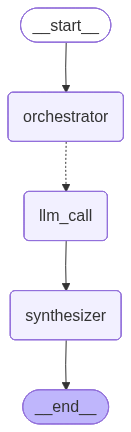

현대 소프트웨어 개발 환경에서 복잡한 워크플로우의 효율적인 관리와 실행은 시스템의 성능과 안정성을 좌우하는 핵심 요소가 되었습니다. 특히 대규모 분산 시스템과 마이크로서비스 아키텍처의 확산으로 인해 다양한 작업 단위들 간의 조율과 협업이 더욱 중요해지고 있습니다.

**랭그래프 오케스트레이션-워커 법칙**은 이러한 배경에서 등장한 개념으로, 그래프 기반의 작업 흐름 관리 시스템에서 오케스트레이터(orchestrator)와 워커(worker) 간의 최적화된 상호작용을 정의하는 일련의 원칙들을 의미합니다. 이 법칙은 작업의 분산, 자원 할당, 실행 순서 결정, 그리고 장애 처리 등의 핵심 영역에서 체계적인 지침을 제공하여 전체 시스템의 처리량과 응답성을 극대화하는 것을 목표로 합니다.

본 연구의 주요 목적은 랭그래프 오케스트레이션-워커 법칙의 이론적 기반을 체계적으로 분석하고, 실제 적용 사례를 통해 그 효과성을 검증하는 것입니다. 또한 현재 산업계에서 사용되고 있는 다양한 오케스트레이션 패턴들과의 비교 분석을 통해 이 법칙의 고유한 장점과 한계점을 명확히 하고자 합니다.

보고서의 구성은 다음과 같습니다. 먼저 관련 기술의 발전 과정과 기존 연구들을 살펴본 후, 랭그래프 오케스트레이션-워커 법칙의 핵심 원리와 구성 요소들을 상세히 분석합니다. 이어서 실제 구현 방법론과 성능 최적화 전략을 제시하고, 다양한 도메인에서의 적용 사례와 그 결과를 검토합니다. 마지막으로 현재의 한계점들을 파악하고 향후 연구 방향을 제시하여 이 분야의 지속적인 발전 가능성을 모색합니다.

---

랭그래프(LangGraph)는 언어 모델의 워크플로우를 그래프 구조로 표현하고 관리하는 혁신적인 프레임워크입니다. 이는 복잡한 AI 애플리케이션에서 다양한 언어 모델 구성 요소들 간의 상호작용을 체계적으로 조직화하고 제어할 수 있도록 설계되었습니다.

## 랭그래프의 정의

랭그래프는 본질적으로 **상태 기반 그래프(Stateful Graph)** 패러다임을 채택한 언어 모델 오케스트레이션 

In [24]:
# 다이어그램 출력
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# 실행
state = orchestrator_worker.invoke({"topic": "랭그래프 오케스트레이션-워커 법칙에 관한 보고서"})
print(state["final_report"])


In [25]:
# 평가자-개선자

# 그래프 상태
class State(TypedDict):
    joke: str          # 현재 농담
    topic: str         # 주제
    feedback: str      # 평가자 피드백(개선 시 참고)
    funny_or_not: str  # 평가 등급("funny" / "not funny")

# 평가에 사용할 구조화 출력 스키마
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="농담이 재미있는지(funny) 아닌지(not funny) 판단하세요."
    )
    feedback: str = Field(
        description="재미없다면 어떻게 개선할지 구체적인 피드백을 작성하세요."
    )

# 평가자 LLM: 구조화 출력으로 등급과 피드백을 반환
evaluator = llm.with_structured_output(Feedback)


In [26]:
# 1) 생성자: 농담 생성(피드백이 있으면 반영하여 개선)
def llm_call_generator(state: State):
    if state.get("feedback"):
        msg = llm.invoke(
            f"주제: {state['topic']}\n"
            f"아래 피드백을 반영하여 더 재미있는 농담을 작성해 주세요.\n"
            f"[피드백]: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"주제: {state['topic']}\n짧고 재치 있는 농담을 작성해 주세요.")
    return {"joke": msg.content}

# 2) 평가자: 농담 평가(등급 + 개선 피드백을 구조화하여 반환)
def llm_call_evaluator(state: State):
    grade = evaluator.invoke(
        f"다음 농담이 재미있는지 평가하고, 필요하면 개선 피드백을 주세요.\n[농담]: {state['joke']}"
    )
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

# 3) 분기: 평가 결과에 따라 종료/재생성 결정
def route_joke(state: State):
    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


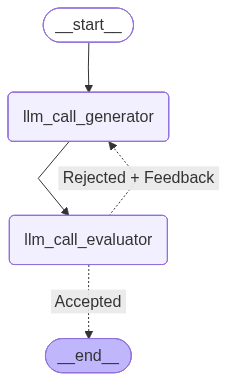

한국인이 해외여행 갈 때 가장 무거운 건 뭘까요?

바로 "라면 챙겨야지" 하는 마음입니다. 🍜

---

김치냉장고가 고장 나면 한국 가정에서 일어나는 일:

전 가족이 모여서... 냉장고 수리기사 번호를 외우게 됩니다. 📞


In [27]:
# 그래프 구성
optimizer_builder = StateGraph(State)
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# 컴파일
optimizer_workflow = optimizer_builder.compile()

# 다이어그램 확인
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

# 실행
state = optimizer_workflow.invoke({"topic": "한국"})
print(state["joke"])


In [28]:
# 에이전트 

from langchain_core.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """두 수를 곱합니다."""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """두 수를 더합니다."""
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """두 수를 나눕니다."""
    return a / b


In [29]:
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage

# LLM 호출 노드
def llm_call(state: MessagesState):
    """LLM이 도구 호출 여부를 결정"""
    return {
        "messages": [
            llm_with_tools.invoke(
                [SystemMessage(content="당신은 주어진 입력값으로 산술 연산을 수행하는 유용한 어시스턴트입니다.")]
                + state["messages"]
            )
        ]
    }


In [30]:
# 도구 실행 노드
def tool_node(state: dict):
    """LLM이 요청한 도구를 실행"""
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


In [31]:
# 반복 여부 판단
def should_continue(state: MessagesState) -> Literal["environment", END]:
    """도구 호출이 있으면 계속, 없으면 종료"""
    if state["messages"][-1].tool_calls:
        return "Action"
    return END


In [32]:
# 에이전트 워크플로 구성
agent_builder = StateGraph(MessagesState)
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {"Action": "environment", END: END},
)
agent_builder.add_edge("environment", "llm_call")

agent = agent_builder.compile()

# 실행
messages = [HumanMessage(content="3과 4를 더하세요.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()


================================ Human Message =================================

3과 4를 더하세요.
================================== Ai Message ==================================

3과 4를 더하겠습니다.
Tool Calls:
  add (toolu_bdrk_01WfRa3aLrvskqCFdKZcN9qd)
 Call ID: toolu_bdrk_01WfRa3aLrvskqCFdKZcN9qd
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

3과 4를 더한 결과는 7입니다.


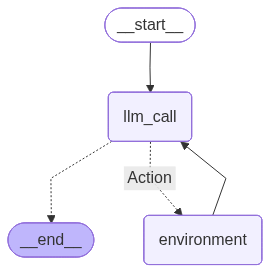

In [33]:
display(Image(agent.get_graph().draw_mermaid_png()))